# Batched singular values: CPU and single-GPU comparison

This notebook compares **singular values only** for batches of real square matrices.  It deliberately tests both `float32` and `float64` and uses the same input matrices for every backend.

Backends, when available:

- NumPy (CPU reference implementation),
- CuPy,
- PyTorch,
- JAX,
- the custom PyCUDA implementation in `custom_pycuda_svals.py`.

Two timing modes are reported for accelerator backends:

1. **device-resident**: the input is already on the accelerator; only the singular-value computation is timed;
2. **end-to-end**: host input -> accelerator -> computation -> host output.

All timings use the same convention: `time.perf_counter()` around the operation plus an explicit synchronization. Compilation/JIT warm-up is excluded. Expected backend unavailability is handled during detection; once a backend is declared available, execution errors are **not** swallowed.

In [1]:
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 9.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for pycuda (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pycuda
Failed to build pycuda
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pycuda)


In [2]:
import time
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None


## Configuration

In [3]:
matrix_size = 4
dtypes = [np.float32, np.float64]
batch_sizes = [32, 128, 512, 2048, 8192]
repeats = 7
seed = 12345
validation_batch_size = 32

assert matrix_size >= 2
assert all(np.dtype(dt) in (np.dtype(np.float32), np.dtype(np.float64)) for dt in dtypes)


## Common timing and validation helpers

For accuracy, accelerator results are compared with a **float64 NumPy reference**, even when the tested backend runs in `float32`. Singular values are sorted before comparison so that a backend-specific ordering convention cannot affect the metric.

In [4]:
@dataclass
class TimingStats:
    median: float
    minimum: float
    maximum: float
    mean: float
    std: float


def summarize_times(samples):
    x = np.asarray(samples, dtype=np.float64)
    return TimingStats(float(np.median(x)), float(np.min(x)), float(np.max(x)),
                       float(np.mean(x)), float(np.std(x)))


def timed_runs(action, synchronize, repeats=repeats):
    """Measure an already-warmed operation using wall-clock time."""
    samples = []
    result = None
    for _ in range(repeats):
        synchronize(None)
        t0 = time.perf_counter()
        result = action()
        synchronize(result)
        samples.append(time.perf_counter() - t0)
    return result, summarize_times(samples)


def make_random_batch(batch_size, dtype, salt=0):
    rng = np.random.default_rng(seed + batch_size + salt)
    return rng.standard_normal((batch_size, matrix_size, matrix_size)).astype(dtype)


def sv_reference(batch):
    return np.linalg.svd(np.asarray(batch, dtype=np.float64), compute_uv=False)


def validation_metrics(values, reference):
    values = np.asarray(values, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)
    if values.shape != reference.shape:
        raise ValueError(f"Shape mismatch: {values.shape} vs {reference.shape}")

    values = np.sort(values, axis=1)[:, ::-1]
    reference = np.sort(reference, axis=1)[:, ::-1]
    finite = np.isfinite(values)
    nonfinite_count = int(values.size - np.count_nonzero(finite))
    if nonfinite_count:
        return {
            'nonfinite_count': nonfinite_count,
            'mean_relative_error': np.inf,
            'median_relative_error': np.inf,
            'max_relative_error': np.inf,
            'max_absolute_error': np.inf,
        }

    diff = values - reference
    denom = np.linalg.norm(reference, axis=1)
    denom = np.maximum(denom, np.finfo(np.float64).tiny)
    per_matrix_rel = np.linalg.norm(diff, axis=1) / denom
    return {
        'nonfinite_count': 0,
        'mean_relative_error': float(np.mean(per_matrix_rel)),
        'median_relative_error': float(np.median(per_matrix_rel)),
        'max_relative_error': float(np.max(per_matrix_rel)),
        'max_absolute_error': float(np.max(np.abs(diff))),
    }


## Backend detection

In [5]:
availability = {}

# CuPy: only import/device-availability failures are treated as unavailability.
try:
    import cupy as cp
except ImportError as exc:
    availability['CuPy'] = (False, f'not installed: {exc}')
else:
    try:
        ndev = cp.cuda.runtime.getDeviceCount()
    except cp.cuda.runtime.CUDARuntimeError as exc:
        availability['CuPy'] = (False, f'CUDA unavailable: {exc}')
    else:
        availability['CuPy'] = (ndev > 0, f'{ndev} CUDA device(s)' if ndev else 'no CUDA device')

try:
    import torch
except ImportError as exc:
    availability['PyTorch'] = (False, f'not installed: {exc}')
else:
    ndev = torch.cuda.device_count() if torch.cuda.is_available() else 0
    availability['PyTorch'] = (ndev > 0, f'{ndev} CUDA device(s)' if ndev else 'CUDA unavailable')

try:
    import jax
except ImportError as exc:
    availability['JAX'] = (False, f'not installed: {exc}')
else:
    # Enable x64 before any JAX arrays are created.
    jax.config.update('jax_enable_x64', True)
    gpu_devices = [d for d in jax.devices() if d.platform == 'gpu']
    availability['JAX'] = (len(gpu_devices) > 0,
                           f'{len(gpu_devices)} GPU device(s)' if gpu_devices else 'no JAX GPU device')

try:
    import pycuda.driver as drv
except ImportError as exc:
    availability['Custom PyCUDA'] = (False, f'not installed: {exc}')
else:
    try:
        drv.init()
        ndev = drv.Device.count()
    except drv.Error as exc:
        availability['Custom PyCUDA'] = (False, f'CUDA unavailable: {exc}')
    else:
        availability['Custom PyCUDA'] = (ndev > 0, f'{ndev} CUDA device(s)' if ndev else 'no CUDA device')

for name, (ok, reason) in availability.items():
    print(f'{name:14s}: {"available" if ok else "unavailable"} ({reason})')


CuPy          : unavailable (not installed: No module named 'cupy')
PyTorch       : unavailable (CUDA unavailable)
JAX           : unavailable (no JAX GPU device)
Custom PyCUDA : unavailable (not installed: No module named 'pycuda')


## Backend implementations

In [6]:
def bench_numpy(batch):
    # Warm-up.
    _ = np.linalg.svd(batch, compute_uv=False)
    action = lambda: np.linalg.svd(batch, compute_uv=False)
    values, stats = timed_runs(action, lambda result: None)
    return values, stats, stats


def solve_numpy(batch):
    return np.linalg.svd(batch, compute_uv=False)


In [7]:
if availability['CuPy'][0]:
    def bench_cupy(batch):
        dtype = cp.float32 if batch.dtype == np.float32 else cp.float64
        x = cp.asarray(batch, dtype=dtype)
        y = cp.linalg.svd(x, full_matrices=False, compute_uv=False)
        cp.cuda.Device().synchronize()

        device_action = lambda: cp.linalg.svd(x, full_matrices=False, compute_uv=False)
        y, device_stats = timed_runs(device_action, lambda result: cp.cuda.Device().synchronize())
        values = cp.asnumpy(y)

        # Warm up the complete host->device->host path once.
        yy = cp.linalg.svd(cp.asarray(batch, dtype=dtype), full_matrices=False, compute_uv=False)
        _ = cp.asnumpy(yy)
        cp.cuda.Device().synchronize()

        def e2e_action():
            xx = cp.asarray(batch, dtype=dtype)
            yy = cp.linalg.svd(xx, full_matrices=False, compute_uv=False)
            return cp.asnumpy(yy)

        e2e_values, e2e_stats = timed_runs(e2e_action, lambda result: cp.cuda.Device().synchronize())
        return e2e_values, device_stats, e2e_stats

    def solve_cupy(batch):
        dtype = cp.float32 if batch.dtype == np.float32 else cp.float64
        return cp.asnumpy(cp.linalg.svd(cp.asarray(batch, dtype=dtype), compute_uv=False))


In [8]:
if availability['PyTorch'][0]:
    def bench_torch(batch):
        dtype = torch.float32 if batch.dtype == np.float32 else torch.float64
        device = torch.device('cuda:0')
        x = torch.as_tensor(batch, dtype=dtype, device=device)
        y = torch.linalg.svdvals(x)
        torch.cuda.synchronize(device)

        device_action = lambda: torch.linalg.svdvals(x)
        y, device_stats = timed_runs(device_action, lambda result: torch.cuda.synchronize(device))
        values = y.detach().cpu().numpy()

        yy = torch.linalg.svdvals(torch.as_tensor(batch, dtype=dtype, device=device))
        _ = yy.detach().cpu().numpy()
        torch.cuda.synchronize(device)

        def e2e_action():
            xx = torch.as_tensor(batch, dtype=dtype, device=device)
            yy = torch.linalg.svdvals(xx)
            return yy.detach().cpu().numpy()

        e2e_values, e2e_stats = timed_runs(e2e_action, lambda result: torch.cuda.synchronize(device))
        return e2e_values, device_stats, e2e_stats

    def solve_torch(batch):
        dtype = torch.float32 if batch.dtype == np.float32 else torch.float64
        device = torch.device('cuda:0')
        x = torch.as_tensor(batch, dtype=dtype, device=device)
        return torch.linalg.svdvals(x).detach().cpu().numpy()


In [9]:
if availability['JAX'][0]:
    import jax.numpy as jnp

    @jax.jit
    def _jax_svals(x):
        return jnp.linalg.svd(x, full_matrices=False, compute_uv=False)

    def bench_jax(batch):
        x = jax.device_put(batch, gpu_devices[0])
        y = _jax_svals(x)
        y.block_until_ready()  # shape/dtype-specific compilation warm-up

        y, device_stats = timed_runs(lambda: _jax_svals(x),
                                     lambda result: result.block_until_ready())
        values = np.asarray(y)

        # Warm up the complete path.
        yy = _jax_svals(jax.device_put(batch, gpu_devices[0]))
        _ = np.asarray(yy)

        def e2e_action():
            xx = jax.device_put(batch, gpu_devices[0])
            yy = _jax_svals(xx)
            return np.asarray(yy)

        e2e_values, e2e_stats = timed_runs(e2e_action, lambda result: None)
        return e2e_values, device_stats, e2e_stats

    def solve_jax(batch):
        x = jax.device_put(batch, gpu_devices[0])
        return np.asarray(_jax_svals(x))


In [10]:
if availability['Custom PyCUDA'][0]:
    # Retain the CUDA primary context so the custom solver can coexist with
    # libraries that also use CUDA's primary context.
    import pycuda.autoprimaryctx
    from custom_pycuda_svals import CustomBatchedSingularValues

    _custom_solver_cache = {}

    def _get_custom_solver(batch):
        key = (len(batch), batch.shape[1], np.dtype(batch.dtype).str)
        solver = _custom_solver_cache.get(key)
        if solver is None:
            solver = CustomBatchedSingularValues(len(batch), batch.shape[1], batch.dtype)
            _custom_solver_cache[key] = solver
        return solver

    def bench_custom_pycuda(batch):
        solver = _get_custom_solver(batch)
        device = solver.benchmark_device(batch, repeats=repeats)
        e2e = solver.benchmark_end_to_end(batch, repeats=repeats)
        return e2e.singular_values, device.timing, e2e.timing

    def solve_custom_pycuda(batch):
        return _get_custom_solver(batch).solve(batch)


## Performance comparison

There is intentionally **no blanket `try/except` around backend execution**. If a backend was detected as available but fails during a benchmark, the notebook stops and exposes the traceback instead of silently labeling the failure as “skipped”.

In [11]:
benchmarks = [('NumPy CPU', bench_numpy)]
if availability['CuPy'][0]: benchmarks.append(('CuPy', bench_cupy))
if availability['PyTorch'][0]: benchmarks.append(('PyTorch', bench_torch))
if availability['JAX'][0]: benchmarks.append(('JAX', bench_jax))
if availability['Custom PyCUDA'][0]: benchmarks.append(('Custom PyCUDA', bench_custom_pycuda))

rows = []
for dtype in dtypes:
    for B in batch_sizes:
        batch = make_random_batch(B, dtype)
        reference = sv_reference(batch)
        print(f'\n{np.dtype(dtype).name}, batch={B}')
        for name, fn in benchmarks:
            values, device_stats, e2e_stats = fn(batch)
            metrics = validation_metrics(values, reference)
            row = {
                'dtype': np.dtype(dtype).name,
                'backend': name,
                'batch_size': B,
                'device_median_s': device_stats.median,
                'device_min_s': device_stats.minimum,
                'device_std_s': device_stats.std,
                'end_to_end_median_s': e2e_stats.median,
                'end_to_end_min_s': e2e_stats.minimum,
                'end_to_end_std_s': e2e_stats.std,
                **metrics,
            }
            rows.append(row)
            print(f"{name:14s} device={device_stats.median:.4e} s  "
                  f"e2e={e2e_stats.median:.4e} s  "
                  f"mean err={metrics['mean_relative_error']:.3e}  "
                  f"max err={metrics['max_relative_error']:.3e}")



float32, batch=32
NumPy CPU      device=1.6117e-04 s  e2e=1.6117e-04 s  mean err=2.272e-08  max err=3.856e-08

float32, batch=128
NumPy CPU      device=6.2483e-04 s  e2e=6.2483e-04 s  mean err=2.268e-08  max err=4.334e-08

float32, batch=512
NumPy CPU      device=1.4574e-02 s  e2e=1.4574e-02 s  mean err=2.328e-08  max err=4.983e-08

float32, batch=2048
NumPy CPU      device=1.9712e-02 s  e2e=1.9712e-02 s  mean err=2.303e-08  max err=5.491e-08

float32, batch=8192
NumPy CPU      device=3.9884e-02 s  e2e=3.9884e-02 s  mean err=2.293e-08  max err=5.548e-08

float64, batch=32
NumPy CPU      device=2.0327e-04 s  e2e=2.0327e-04 s  mean err=0.000e+00  max err=0.000e+00

float64, batch=128
NumPy CPU      device=5.6530e-04 s  e2e=5.6530e-04 s  mean err=0.000e+00  max err=0.000e+00

float64, batch=512
NumPy CPU      device=2.2165e-03 s  e2e=2.2165e-03 s  mean err=0.000e+00  max err=0.000e+00

float64, batch=2048
NumPy CPU      device=8.7683e-03 s  e2e=8.7683e-03 s  mean err=0.000e+00  max err=0

In [12]:
if pd is not None:
    performance_results = pd.DataFrame(rows)
    display(performance_results)
else:
    performance_results = rows
    for row in rows:
        print(row)


,dtype,backend,batch_size,device_median_s,device_min_s,device_std_s,end_to_end_median_s,end_to_end_min_s,end_to_end_std_s,nonfinite_count,mean_relative_error,median_relative_error,max_relative_error,max_absolute_error
0,float32,NumPy CPU,32,0.000161,0.000155,0.000449,0.000161,0.000155,0.000449,0,2.272021e-08,2.239934e-08,3.856031e-08,1.163997e-07
1,float32,NumPy CPU,128,0.000625,0.000516,0.000904,0.000625,0.000516,0.000904,0,2.267548e-08,2.346281e-08,4.333910e-08,2.141564e-07
2,float32,NumPy CPU,512,0.014574,0.005349,0.010480,0.014574,0.005349,0.010480,0,2.327500e-08,2.360729e-08,4.982511e-08,2.266223e-07
3,float32,NumPy CPU,2048,0.019712,0.016093,0.001652,0.019712,0.016093,0.001652,0,2.302510e-08,2.256016e-08,5.490602e-08,2.368791e-07
4,float32,NumPy CPU,8192,0.039884,0.037203,0.003574,0.039884,0.037203,0.003574,0,2.292615e-08,2.262736e-08,5.547552e-08,2.379205e-07
5,float64,NumPy CPU,32,0.000203,0.000167,0.000484,0.000203,0.000167,0.000484,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,float64,NumPy CPU,128,0.000565,0.000325,0.000600,0.000565,0.000325,0.000600,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,float64,NumPy CPU,512,0.002217,0.002183,0.000440,0.002217,0.002183,0.000440,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,float64,NumPy CPU,2048,0.008768,0.007760,0.000422,0.008768,0.007760,0.000422,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,float64,NumPy CPU,8192,0.099362,0.036551,0.027498,0.099362,0.036551,0.027498,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


## Numerical validation on structured cases

In [13]:
def random_orthogonal_batch(rng, B, n):
    q, r = np.linalg.qr(rng.standard_normal((B, n, n)))
    # Fix the arbitrary QR signs to make generation deterministic.
    signs = np.sign(np.diagonal(r, axis1=1, axis2=2))
    signs[signs == 0] = 1
    return q * signs[:, None, :]


def make_controlled_spectrum_batch(B, dtype, condition_number, scale=1.0, salt=0):
    rng = np.random.default_rng(seed + 100000 + salt)
    U = random_orthogonal_batch(rng, B, matrix_size)
    V = random_orthogonal_batch(rng, B, matrix_size)
    s = np.geomspace(scale, scale / condition_number, matrix_size)
    A = (U * s[None, None, :]) @ np.swapaxes(V, 1, 2)
    reference = np.repeat(s[None, :], B, axis=0)
    return A.astype(dtype), reference


def make_validation_cases(dtype):
    B = validation_batch_size
    cases = {}

    A = np.zeros((B, matrix_size, matrix_size), dtype=dtype)
    diagonal = np.geomspace(1.0, 1e-3, matrix_size)
    for i in range(B):
        signs = np.where(((i + np.arange(matrix_size)) % 2) == 0, 1.0, -1.0)
        A[i] = np.diag(diagonal * signs)
    cases['diagonal'] = (A, np.repeat(diagonal[None, :], B, axis=0))

    cases['zero'] = (np.zeros_like(A), np.zeros((B, matrix_size), dtype=np.float64))

    rank_s = np.linspace(1.0, 0.25, matrix_size)
    rank_s[-1] = 0.0
    rng = np.random.default_rng(seed + 222)
    U = random_orthogonal_batch(rng, B, matrix_size)
    V = random_orthogonal_batch(rng, B, matrix_size)
    A_rank = (U * rank_s[None, None, :]) @ np.swapaxes(V, 1, 2)
    cases['rank_deficient'] = (A_rank.astype(dtype), np.repeat(rank_s[None, :], B, axis=0))

    cond = 1e4 if np.dtype(dtype) == np.dtype(np.float32) else 1e10
    cases[f'condition_{cond:.0e}'] = make_controlled_spectrum_batch(B, dtype, cond, salt=333)

    # Same condition number at widely different global scales. Keep the
    # validation batch size fixed so the custom solver can reuse its compiled
    # kernels from the performance run.
    rng = np.random.default_rng(seed + 444)
    U = random_orthogonal_batch(rng, B, matrix_size)
    V = random_orthogonal_batch(rng, B, matrix_size)
    scales = np.geomspace(1e-6, 1e6, B)
    base_s = np.geomspace(1.0, 1e-3, matrix_size)
    spectra = scales[:, None] * base_s[None, :]
    A_scale = (U * spectra[:, None, :]) @ np.swapaxes(V, 1, 2)
    cases['wide_global_scale'] = (A_scale.astype(dtype), spectra)
    return cases


solvers = [('NumPy CPU', solve_numpy)]
if availability['CuPy'][0]: solvers.append(('CuPy', solve_cupy))
if availability['PyTorch'][0]: solvers.append(('PyTorch', solve_torch))
if availability['JAX'][0]: solvers.append(('JAX', solve_jax))
if availability['Custom PyCUDA'][0]: solvers.append(('Custom PyCUDA', solve_custom_pycuda))

validation_rows = []
for dtype in dtypes:
    cases = make_validation_cases(dtype)
    for case_name, (batch, reference) in cases.items():
        for name, solve_fn in solvers:
            values = solve_fn(batch)
            metrics = validation_metrics(values, reference)
            validation_rows.append({
                'dtype': np.dtype(dtype).name,
                'case': case_name,
                'backend': name,
                **metrics,
            })

if pd is not None:
    validation_results = pd.DataFrame(validation_rows)
    display(validation_results)
else:
    validation_results = validation_rows
    for row in validation_rows:
        print(row)


,dtype,case,backend,nonfinite_count,mean_relative_error,median_relative_error,max_relative_error,max_absolute_error
0,float32,diagonal,NumPy CPU,0,1.499978e-09,1.499978e-09,1.499978e-09,1.490116e-09
1,float32,zero,NumPy CPU,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,float32,rank_deficient,NumPy CPU,0,5.610422e-09,3.380985e-09,4.433355e-08,5.960464e-08
3,float32,condition_1e+04,NumPy CPU,0,6.469758e-09,4.527393e-09,5.971145e-08,5.960464e-08
4,float32,wide_global_scale,NumPy CPU,0,2.795609e-08,2.484203e-08,6.570433e-08,1.955513e-02
5,float64,diagonal,NumPy CPU,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,float64,zero,NumPy CPU,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,float64,rank_deficient,NumPy CPU,0,2.614402e-16,2.481591e-16,5.532166e-16,6.661338e-16
8,float64,condition_1e+10,NumPy CPU,0,1.862765e-16,2.235282e-16,4.461199e-16,4.440892e-16
9,float64,wide_global_scale,NumPy CPU,0,2.008976e-16,1.982421e-16,4.794008e-16,4.656613e-10


### How to read the validation table

- `nonfinite_count` must be zero.
- `mean_relative_error` and `max_relative_error` compare the complete singular-value vector of each matrix with the known/reference spectrum.
- `max_absolute_error` is useful for rank-deficient and zero cases, where a componentwise relative error would be ill-defined.
- The controlled-condition-number cases intentionally probe regimes where numerical sensitivity is expected to increase. They are diagnostics, not assumptions that every method must attain the same accuracy at every condition number.

## Plots

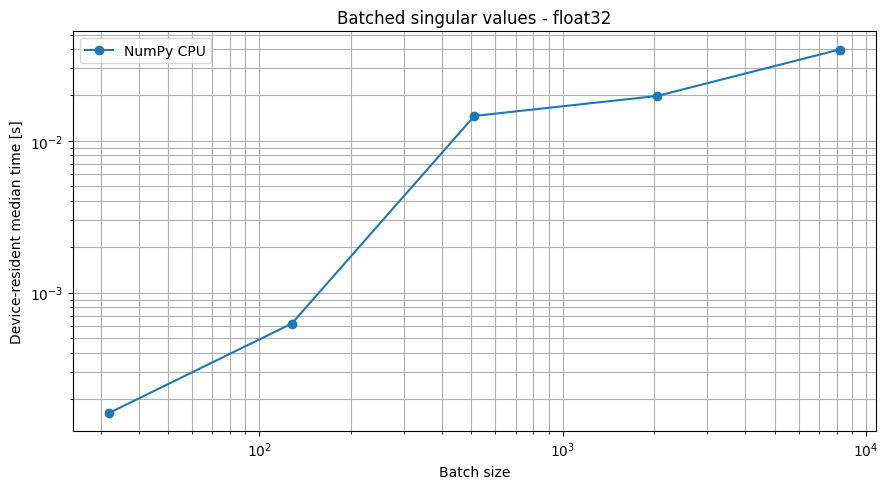

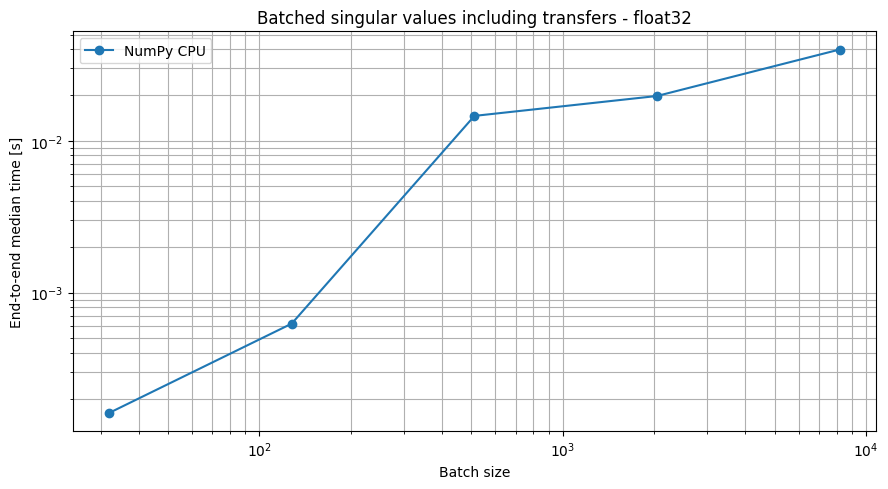

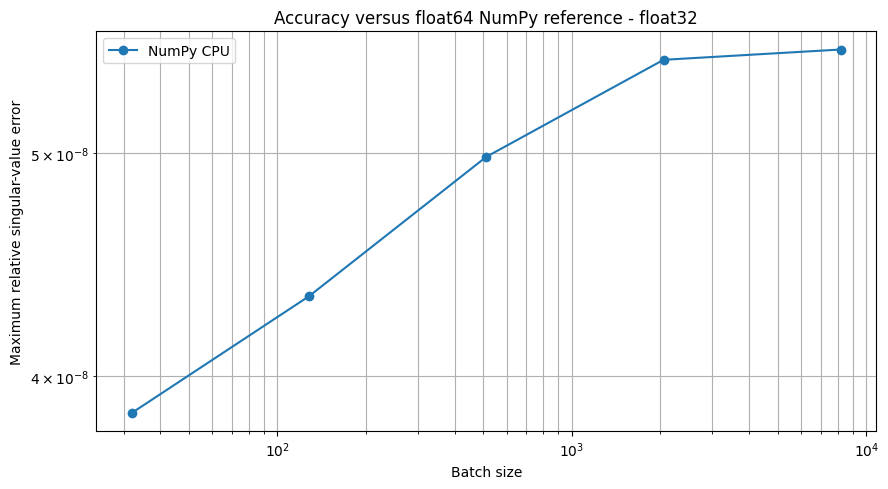

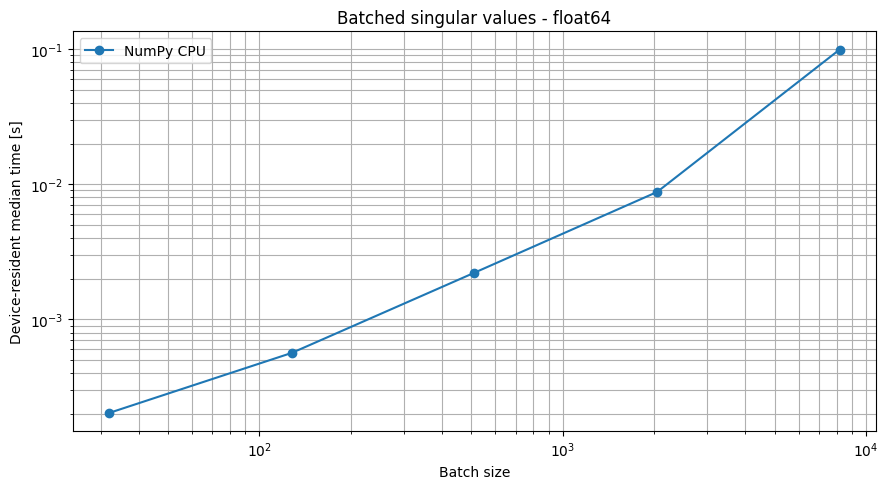

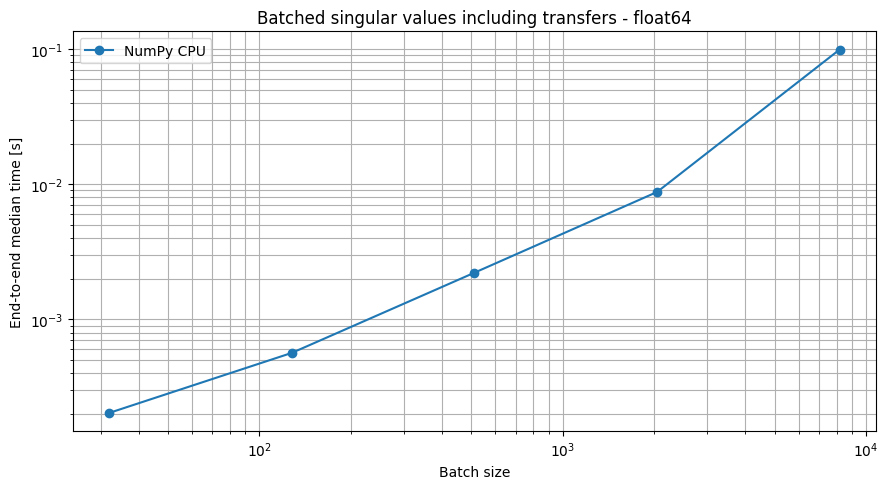

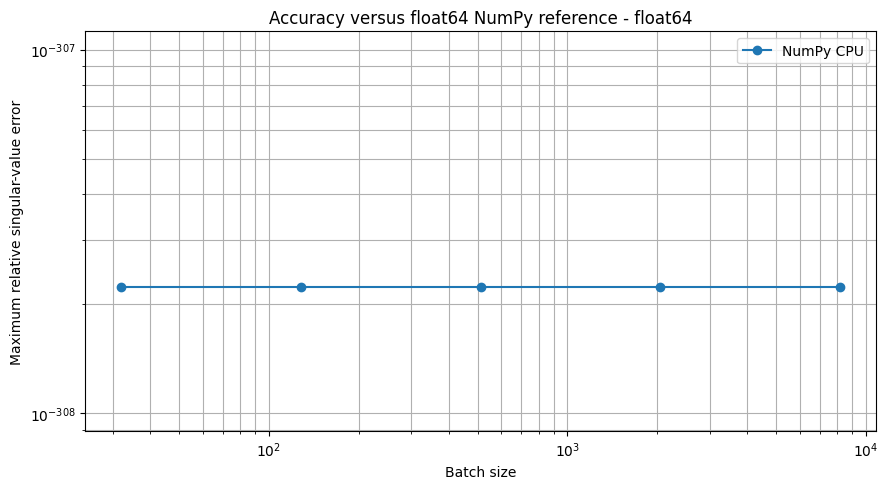

In [14]:
if pd is not None and len(performance_results):
    for dtype_name in performance_results['dtype'].unique():
        sub = performance_results[performance_results['dtype'] == dtype_name]

        plt.figure(figsize=(9, 5))
        for name, group in sub.groupby('backend'):
            plt.loglog(group['batch_size'], group['device_median_s'], marker='o', label=name)
        plt.xlabel('Batch size')
        plt.ylabel('Device-resident median time [s]')
        plt.title(f'Batched singular values - {dtype_name}')
        plt.grid(True, which='both')
        plt.legend(); plt.tight_layout(); plt.show()

        plt.figure(figsize=(9, 5))
        for name, group in sub.groupby('backend'):
            plt.loglog(group['batch_size'], group['end_to_end_median_s'], marker='o', label=name)
        plt.xlabel('Batch size')
        plt.ylabel('End-to-end median time [s]')
        plt.title(f'Batched singular values including transfers - {dtype_name}')
        plt.grid(True, which='both')
        plt.legend(); plt.tight_layout(); plt.show()

        plt.figure(figsize=(9, 5))
        for name, group in sub.groupby('backend'):
            y = np.maximum(group['max_relative_error'].to_numpy(), np.finfo(float).tiny)
            plt.loglog(group['batch_size'], y, marker='o', label=name)
        plt.xlabel('Batch size')
        plt.ylabel('Maximum relative singular-value error')
        plt.title(f'Accuracy versus float64 NumPy reference - {dtype_name}')
        plt.grid(True, which='both')
        plt.legend(); plt.tight_layout(); plt.show()


In [15]:
if availability['Custom PyCUDA'][0]:
    # Explicitly release cached custom-solver device allocations.
    for solver in _custom_solver_cache.values():
        solver.close()
    _custom_solver_cache.clear()


## Notes

- The custom PyCUDA solver is intentionally restricted to **real square matrices**.
- No singular vectors are computed because the custom implementation provides singular values only.
- The default benchmark sizes are conservative. Increase them after confirming available GPU memory.
- The dedicated `CompareMultiGPUBatchedSingularValues.ipynb` notebook studies explicit batch partitioning across several GPUs.